# 🌿 Plant Recognition with CLIP + FAISS (Parallel 10x Faster)

## 📦 1. Instalação

In [1]:
!pip install -q torch torchvision faiss-cpu transformers requests tqdm pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 54.3 MB/s eta 0:00:00


## 📚 2. Imports + Config

In [2]:
import os, requests, torch, faiss, numpy as np
from PIL import Image
from io import BytesIO
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from transformers import CLIPProcessor, CLIPModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TARGET_SPECIES = 5000
IMAGES_PER_SPECIES = 50
MAX_WORKERS = 16

## 🤖 3. CLIP

In [3]:
model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(DEVICE)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

## 🌱 4. Lista de espécies

In [5]:
def get_species_list(target=5000):
    species, page = [], 1
    while len(species) < target:
        res = requests.get("https://api.inaturalist.org/v1/taxa", params={
            "taxon_id": 47126, "rank": "species", "per_page": 200, "page": page
        }).json()
        for item in res.get("results", []):
            if item.get("name"):
                description = item.get("preferred_common_name") or ""
                species.append({
                    "name": item["name"],
                    "description": description
                })
        page += 1
    return species[:target]

species_list = get_species_list(TARGET_SPECIES)
species_names = [s["name"] for s in species_list]
species_metadata = {
    s["name"]: s["description"] for s in species_list
}

## 🧠 5. Embeddings

In [6]:
def generate_embeddings(images):
    inputs = processor(images=images, return_tensors="pt", padding=True)
    pixel_values = inputs["pixel_values"].to(DEVICE)

    with torch.no_grad():
        outputs = model.get_image_features(pixel_values=pixel_values)

    # 🔥 garante tensor independente da versão
    if isinstance(outputs, torch.Tensor):
        feats = outputs
    elif hasattr(outputs, "image_embeds"):
        feats = outputs.image_embeds
    elif hasattr(outputs, "pooler_output"):
        feats = outputs.pooler_output
    else:
        raise ValueError(f"Unexpected output type: {type(outputs)}")

    return feats.detach().cpu().numpy()

## ⚡ 6. Download paralelo + incremental

In [7]:
index = None
labels_all = []

def download_species(sp):
    images, labels = [], []
    try:
        res = requests.get("https://api.inaturalist.org/v1/observations", params={
            "taxon_name": sp,
            "per_page": IMAGES_PER_SPECIES,
            "photos": True,
            "quality_grade": "research"
        }).json()

        for obs in res.get("results", []):
            if obs.get("photos"):
                url = obs["photos"][0]["url"].replace("square", "medium")
                img = Image.open(BytesIO(requests.get(url, timeout=5).content)).convert("RGB")
                images.append(img)
                labels.append(sp)
    except:
        pass
    return images, labels


def run_parallel(species_list, batch_size=200):
    global index, labels_all

    for i in range(0, len(species_list), batch_size):
        batch = species_list[i:i+batch_size]

        imgs, labs = [], []
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
            futures = [ex.submit(download_species, sp) for sp in batch]
            for f in tqdm(as_completed(futures), total=len(futures)):
                im, lb = f.result()
                imgs.extend(im)
                labs.extend(lb)

        if not imgs:
            continue

        emb = generate_embeddings(imgs)
        faiss.normalize_L2(emb)

        if index is None:
            index = faiss.IndexFlatIP(emb.shape[1])

        index.add(emb)
        labels_all.extend(labs)

        np.save("labels.npy", np.array(labels_all))
        faiss.write_index(index, "plants.index")
        np.save("species_metadata.npy", species_metadata)

        print(f"Saved até {i + batch_size}")

run_parallel(species_list)

100%|██████████| 200/200 [00:00<00:00, 205.09it/s]


## 🔍 7. Inferência Top-5

In [8]:
def predict(image_path, top_k=5):
    img = Image.open(image_path).convert("RGB")
    emb = generate_embeddings([img])
    faiss.normalize_L2(emb)

    D, I = index.search(emb, top_k)

    return [
        {"species": labels_all[idx], "confidence": float(score)}
        for idx, score in zip(I[0], D[0])
    ]

## 🧪 8. Teste

In [9]:
from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

Saving Samambaia-Americana-C21.png to Samambaia-Americana-C21.png


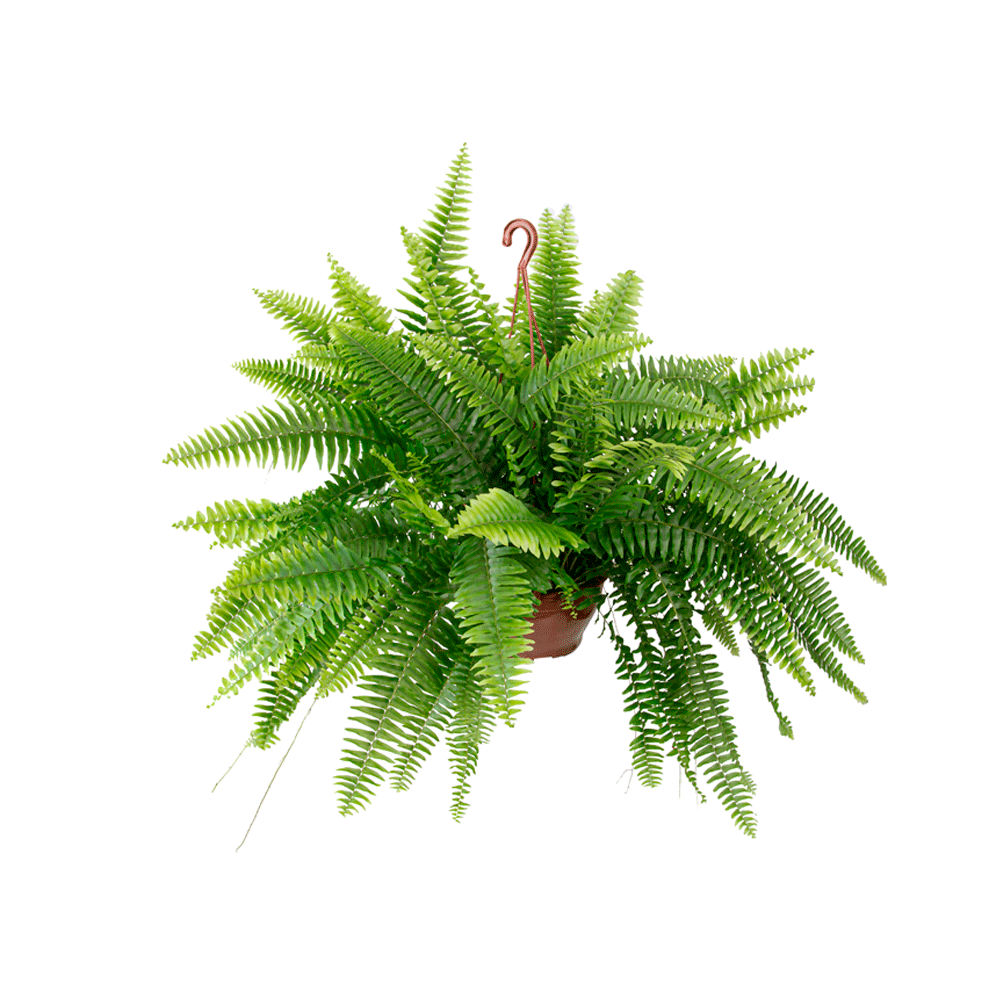

AttributeError: 'NoneType' object has no attribute 'search'

In [10]:
from IPython.display import Image as DisplayImage, display
from PIL import Image # Re-import PIL.Image to ensure 'Image' refers to PIL's Image

# Display the uploaded image using the aliased IPython.display.Image
display(DisplayImage(filename=img_path, width=200))

# Predict the species (now 'Image' inside predict will be PIL.Image)
predictions = predict(img_path)

# Get the top prediction
if predictions:
    top_prediction = predictions[0]
    print(f"Predicted Species: {top_prediction['species']} (Confidence: {top_prediction['confidence']:.2f})")
else:
    print("No predictions found.")